## About Dataset


About Dataset
Context

    "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [TeleCo Customer Data Sets]

Content

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

    Customers who left within the last month – the column is called Churn
    Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
    Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
    Demographic info about customers – gender, age range, and if they have partners and dependents



Exploration and Dataloading


In [1]:
import pandas as pd
import numpy as np
from joblib import dump
import os
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import  RandomForestClassifier,VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import  matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score
from sklearn.metrics import classification_report, roc_auc_score

In [ ]:
df=f"C:\\Users\\User\\Desktop\\workshop\\New folder\\New folder\\Prediction\\data\\WA_Fn-UseC_-Telco-Customer-Churn.csv"
print(os.path.exists(df))
data=pd.read_csv(df)
data.head()

True


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Cleaning and SplittingData

In [3]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
print(data['Churn'].dtype)

object


In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')
data["TotalCharges"].isnull().sum()
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:


X=data.drop(['customerID', 'Churn'], axis=1)
y=data['Churn'].apply(lambda x:1 if x=="Yes" else 0)
data_temp = data.copy()
data_temp['Churn_numeric'] = y

# Compute correlations
corr_matrix = data_temp.corr(numeric_only=True)

# Get correlations with y
churn_corr = corr_matrix['Churn_numeric'].sort_values(ascending=False)
print(churn_corr)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
num_col=X.select_dtypes(include=['int64', 'float64']).columns
cat_col=X.select_dtypes(include=['object']).columns
X.info()

y.info()


Churn_numeric     1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199037
tenure           -0.352229
Name: Churn_numeric, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMov

In [7]:
X.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

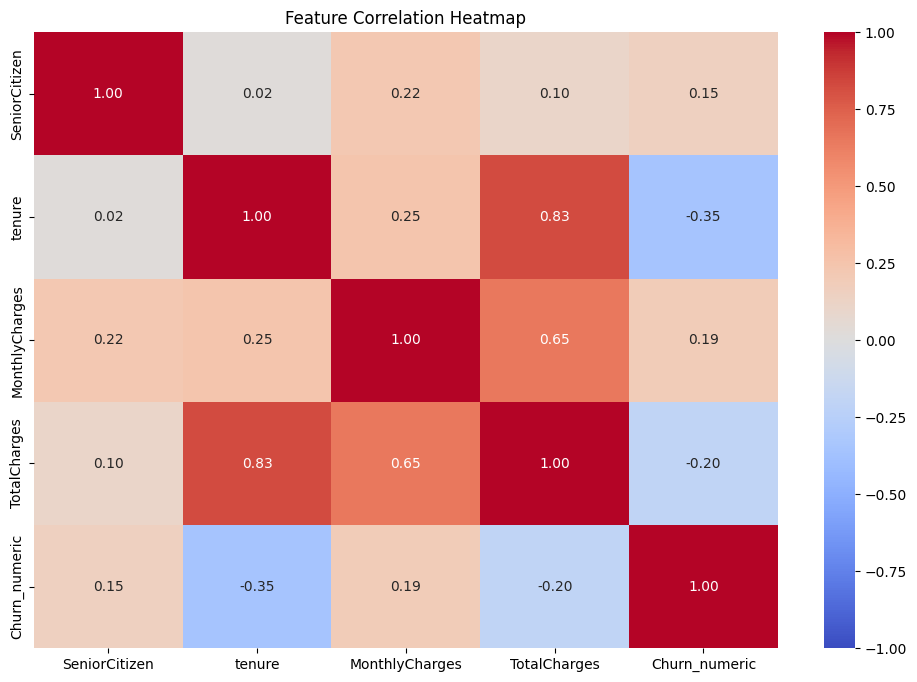

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix.fillna(0), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, vmax=1
)
plt.title("Feature Correlation Heatmap")
plt.show()

Feature Engineering and Pipeline

In [9]:
num_col=X.select_dtypes(include=['int64', 'float64']).columns
cat_col=X.select_dtypes(include=['object']).columns
num_pipeline=Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_pipeline=Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),
                             ('enoder', OneHotEncoder(handle_unknown='ignore'))])

In [10]:

cat_col.isnull().sum()

np.int64(0)

Machine Learning

In [11]:
rf=RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced',n_jobs=-1)
lr=LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced',n_jobs=-1)
lg=LGBMClassifier(n_estimators=100, random_state=42,class_weight='balanced',n_jobs=-1,learning_rate=0.05)
xg=XGBClassifier( n_estimators=100,
    random_state=42,
    n_jobs=-1,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss')
Voting=VotingClassifier(estimators=[('rf',rf),('lr',lr),('xl',lg),('xg',xg)],voting='soft',n_jobs=-1,weights=[1,1,2,3],)
processor=ColumnTransformer(transformers=[('num',num_pipeline,num_col),
                                          ('cat',cat_pipeline,cat_col)])
model=Pipeline(steps=[('preprocessor',processor),('classifier',Voting)])
model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Prediction and Metrics

In [12]:
TRESHOLD= 0.3
xtest=model.named_steps['preprocessor'].transform(X_test)
for name, estimator in model.named_steps['classifier'].named_estimators_.items():
    y_pred = estimator.predict_proba(xtest)[:, 1]
    y_pred = (y_pred >= TRESHOLD).astype(int)
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred,labels=[0,1]))
    print(f"ROC AUC Score: {roc_auc_score(y_test, estimator.predict_proba(xtest)[:, 1])}\n")

Model: rf
              precision    recall  f1-score   support

           0       0.88      0.76      0.81      1035
           1       0.51      0.70      0.59       374

    accuracy                           0.74      1409
   macro avg       0.69      0.73      0.70      1409
weighted avg       0.78      0.74      0.76      1409

ROC AUC Score: 0.8193249631868558

Model: lr
              precision    recall  f1-score   support

           0       0.95      0.55      0.70      1035
           1       0.43      0.93      0.59       374

    accuracy                           0.65      1409
   macro avg       0.69      0.74      0.64      1409
weighted avg       0.82      0.65      0.67      1409

ROC AUC Score: 0.8412978893797307

Model: xl
              precision    recall  f1-score   support

           0       0.94      0.61      0.74      1035
           1       0.45      0.89      0.60       374

    accuracy                           0.69      1409
   macro avg       0.70     

c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
xtest=model.named_steps['preprocessor'].transform(X_test)

for name, estimator in model.named_steps['classifier'].named_estimators_.items():
    y_pred = estimator.predict(xtest)
    print(f"Model: {name}")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_test, estimator.predict_proba(xtest)[:, 1])}\n")

Model: rf
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1035
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC AUC Score: 0.8193249631868558

Model: lr
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC AUC Score: 0.8412978893797307

Model: xl
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71     

c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [14]:
TRESHOLD= 0.3
pred=model.predict(X_test)
proba=model.predict_proba(X_test)[:,1]
y_pred=(proba>=TRESHOLD).astype(int)


print(classification_report(y_test, y_pred, labels=[0,1]))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred))

c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.92      0.68      0.79      1035
           1       0.49      0.84      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.70      1409
weighted avg       0.81      0.73      0.74      1409

Accuracy: 0.7260468417317246
AUC Score: 0.7640057867679351


In [15]:
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred_thresh = (proba >= thresh).astype(int)
    precision_1 = precision_score(y_test, y_pred_thresh, pos_label=1)
    recall_1 = recall_score(y_test, y_pred_thresh, pos_label=1)
    f1_1 = f1_score(y_test, y_pred_thresh, pos_label=1)
    print(f"{thresh:<8.3f}{precision_1:<8.3f}{recall_1:<8.3f}{f1_1:<8.3f}")


Thresh  Prec_1  Rec_1   F1_1    
0.250   0.460   0.869   0.602   
0.300   0.491   0.845   0.621   
0.350   0.517   0.802   0.629   
0.400   0.538   0.762   0.631   
0.450   0.552   0.701   0.617   
0.500   0.577   0.634   0.604   


HYPERPARAMETER TUNING (MLFLOW)

In [16]:
import os
import time
import mlflow
import mlflow.sklearn
import optuna
import numpy as np

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

# =========================
# Setup MLflow
# =========================
# Use absolute path with forward slashes
project_root = os.path.abspath(os.path.join(os.getcwd(), "..")).replace("\\", "/")
mlruns_path = f"file:///{project_root}/mlruns"

mlflow.set_tracking_uri(mlruns_path)

# Create or set experiment
mlflow.set_experiment(experiment_name="Telco Churn - VotingClassifier Optuna")

# =========================
# Assume your fitted pipeline is already defined
# model = Pipeline([
#     ('preprocessor', preprocessor),
#     ('classifier', Voting)
# ])
# =========================

# Extract already preprocessed features
Xt_train = model.named_steps['preprocessor'].transform(X_train)
Xt_test = model.named_steps['preprocessor'].transform(X_test)
y_train = y_train  # your training labels
y_test = y_test    # your test labels

# =========================
# Define Optuna objective to tune VotingClassifier
# =========================
def objective(trial):
    # Hyperparameter search space
    
    rf_n_estimators = trial.suggest_int("rf_n_estimators", 50, 200)
    rf_max_depth = trial.suggest_int("rf_max_depth", 3, 10)

    lg_n_estimators = trial.suggest_int("lg_n_estimators", 50, 200)
    lg_learning_rate = trial.suggest_float("lg_learning_rate", 0.01, 0.1)

    xg_n_estimators = trial.suggest_int("xg_n_estimators", 50, 200)
    xg_learning_rate = trial.suggest_float("xg_learning_rate", 0.01, 0.1)
    xg_max_depth = trial.suggest_int("xg_max_depth", 3, 10)

    # Base models
    rf = RandomForestClassifier(
        n_estimators=rf_n_estimators,
        max_depth=rf_max_depth,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    )
    lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
    lg = LGBMClassifier(n_estimators=lg_n_estimators, learning_rate=lg_learning_rate,
                        random_state=42, class_weight='balanced', n_jobs=-1)
    xg = XGBClassifier(n_estimators=xg_n_estimators, learning_rate=xg_learning_rate,
                       max_depth=xg_max_depth, random_state=42, n_jobs=-1, eval_metric='logloss')

    Voting_trial = VotingClassifier(
        estimators=[('rf', rf), ('lr', lr), ('lg', lg), ('xg', xg)],
        voting='soft',
        n_jobs=-1,
        weights=[1,1,2,3]
    )

    # Fit only VotingClassifier on preprocessed features
    Voting_trial.fit(Xt_train, y_train)

    THRESHOLD = 0.3
    proba = Voting_trial.predict_proba(Xt_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    auc = roc_auc_score(y_test, proba)
    return auc

# =========================
# Run Optuna
# =========================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

# =========================
# Train final VotingClassifier with best params
# =========================
best_params = study.best_params

rf_best = RandomForestClassifier(
    n_estimators=best_params.get("rf_n_estimators", 100),
    max_depth=best_params.get("rf_max_depth", None),
    random_state=42, class_weight='balanced', n_jobs=-1
)
lr_best = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', n_jobs=-1)
lg_best = LGBMClassifier(
    n_estimators=best_params.get("lg_n_estimators", 100),
    learning_rate=best_params.get("lg_learning_rate", 0.05),
    random_state=42, class_weight='balanced', n_jobs=-1
)
xg_best = XGBClassifier(
    n_estimators=best_params.get("xg_n_estimators", 100),
    learning_rate=best_params.get("xg_learning_rate", 0.05),
    max_depth=best_params.get("xg_max_depth", 6),
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

Voting_best = VotingClassifier(
    estimators=[('rf', rf_best), ('lr', lr_best), ('lg', lg_best), ('xg', xg_best)],
    voting='soft',
    n_jobs=-1,
    weights=[1,1,2,3]
)

# =========================
# MLflow logging
# =========================
THRESHOLD = 0.3
with mlflow.start_run(run_name="VotingPipeline_Preprocessed"):

    mlflow.log_params(best_params)
    mlflow.log_param("threshold", THRESHOLD)

    # Fit on preprocessed features
    start_train = time.time()
    Voting_best.fit(Xt_train, y_train)
    mlflow.log_metric("train_time", time.time() - start_train)

    # Predict
    proba = Voting_best.predict_proba(Xt_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, proba)

    mlflow.log_metrics({
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    })

    # Log VotingClassifier only (preprocessor already fitted)
    mlflow.sklearn.log_model(Voting_best, artifact_path="voting_model")

    # Output
    print("\n===== Classification Report =====")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC: {roc_auc:.4f}")

c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
[I 2026-03-06 16:56:44,022] A new study created in memory with name: no-name-98b4887f-2e09-4026-b2d0-b0afe92d68c0
c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\ut

Best AUC: 0.8473610788188793
Best params: {'rf_n_estimators': 112, 'rf_max_depth': 7, 'lg_n_estimators': 50, 'lg_learning_rate': 0.01850213139269222, 'xg_n_estimators': 141, 'xg_learning_rate': 0.0476765848517251, 'xg_max_depth': 4}


c:\Users\User\Desktop\workshop\New folder\New folder\Prediction\venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
2026/03/06 16:57:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/06 16:57:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



===== Classification Report =====
              precision    recall  f1-score   support

           0       0.93      0.63      0.75      1035
           1       0.46      0.87      0.60       374

    accuracy                           0.69      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.69      0.71      1409

ROC AUC: 0.8474


                                    Feature  Importance
2                            MonthlyCharges         684
3                              TotalCharges         626
1                                    tenure         498
43           PaymentMethod_Electronic check         103
39                      PaperlessBilling_No          79
4                             gender_Female          67
27                           TechSupport_No          64
21                          OnlineBackup_No          64
18                        OnlineSecurity_No          63
12                         MultipleLines_No          57
36                  Contract_Month-to-month          56
0                             SeniorCitizen          51
37                        Contract_One year          50
41  PaymentMethod_Bank transfer (automatic)          48
8                             Dependents_No          42
33                       StreamingMovies_No          41
38                        Contract_Two year     

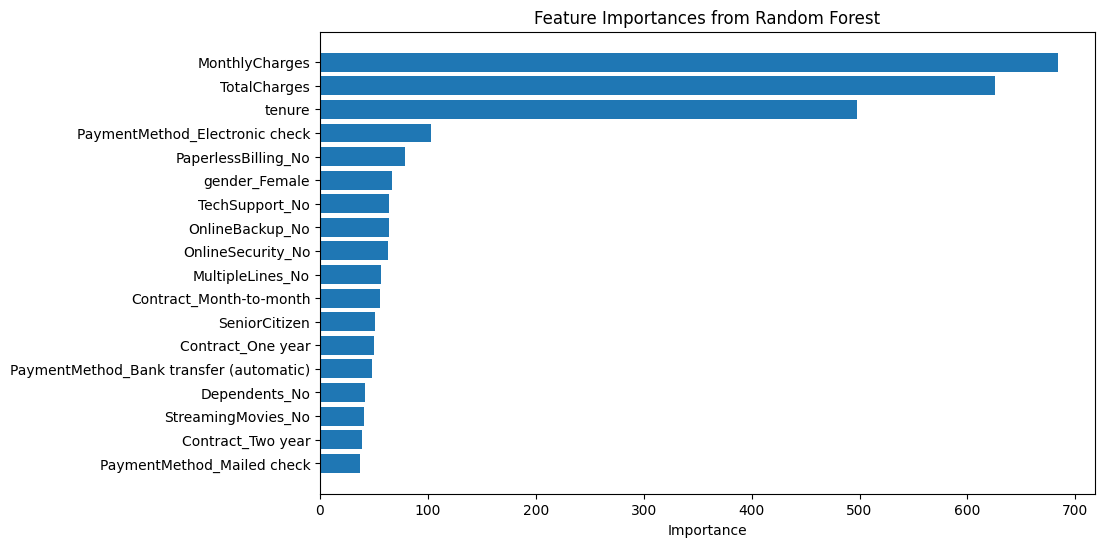

In [17]:
num_feature=num_col
cat_features=model.named_steps['preprocessor'].transformers_[1][1] \
      .named_steps['enoder'].get_feature_names_out(cat_col)
feature=np.concatenate([num_feature,cat_features])
importances=model.named_steps['classifier'].named_estimators_['xl'].feature_importances_
feature_importances=pd.DataFrame({'Feature':feature,'Importance':importances}).sort_values(by='Importance',ascending=False)
print(feature_importances.head(20))
plt.figure(figsize=(10,6))
plt.barh(feature_importances['Feature'].head(20)[:-2], feature_importances['Importance'].head(20)[:-2])
plt.xlabel('Importance')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [18]:
from pathlib import Path
import joblib

ARTIFACTS_DIR = Path("..") / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)

joblib.dump(model, ARTIFACTS_DIR / "churn_model1.pkl")

['..\\artifacts\\churn_model1.pkl']